# Green's Function Analysis (corrected)

Green's function approach to Rossi-alpha, following
> Gabrieli, Shokef, Neder (2025), *Efficient calculation of reactor noise via Ito-Langevin Process*.

## Method
For each spatial cell $i$ we need $g_i(t)$ — the detector response per neutron **emitted from
cell $i$**, following its entire fission chain — and its time integral
$G_i=\int g_i(t)\,dt$. The Rossi-alpha is then (Eq. 55):
$$R(\tau)=\sum_i F_i \int g_i(t)\,g_i(t+\tau)\,dt,\qquad F_i=\overline{\nu(\nu-1)}\,\tilde F_i .$$

**Why this notebook was rewritten.** The original pipeline ran one uniform-source simulation
and attributed each detection back to a birth cell via `mesh_ids[parent_id-1]`. But
`openmc.FileSource` samples a *random* site per history, so the particle `id` does **not**
equal the pre-generated source-file row — the attribution was scrambled and forced
$G_i=\text{det}_i/\text{src}_i\to\text{const}$ (a flat map at every $k$). The corrected
data here comes from `project.simulations.greens_sweep`: **one confined-source simulation per
cell**, so every detection originates from that cell *by construction* — no `parent_id`,
no bug. See `greens_per_cell.py` for the ground-truth proof (near/far pole ratio 7-50x).

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from project.analysis import greens_loader as gl

FIGURES_DIR = Path("../outputs/figures/greens_function")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL = "098"
sweep = gl.load_sweep(LABEL)
n_r, n_th = sweep["G"].shape
F = gl.fission_coarse(LABEL, n_r, n_th)

R = float(sweep["R"]); det_z = R + 15.0
print(f"k = {sweep['k']:.2f}   R = {R:.2f} cm   detector at +Z = {det_z:.1f} cm")
print(f"coarse grid: {n_r} radial x {n_th} theta = {n_r*n_th} cells, "
      f"{sweep['n_source']:,} source neutrons/cell")
print(f"G range: {sweep['G'].min():.2e} .. {sweep['G'].max():.2e}  "
      f"(buggy flat method gave ~{sweep['G'].mean():.2e} everywhere)")

k = 0.98   R = 28.70 cm   detector at +Z = 43.7 cm
coarse grid: 20 radial x 20 theta = 400 cells, 100,000 source neutrons/cell
G range: 4.69e-03 .. 6.37e-02  (buggy flat method gave ~2.63e-02 everywhere)


## 0. Setup: detector & mesh geometry

Before any results, confirm the geometry means what we claim. The detector sits on the **+Z axis**,
which is the polar axis of the spherical tally mesh ($\theta$ is measured from +Z). So $\cos\theta=+1$
is the detector-facing surface and $\cos\theta=-1$ the far side, every $(r,\theta)$ cell has a
well-defined distance to the detector, and the detector is *outside* the core (10 cm gap). This is
what makes the spatial $G_i$ interpretable as a function of distance/direction to the detector.

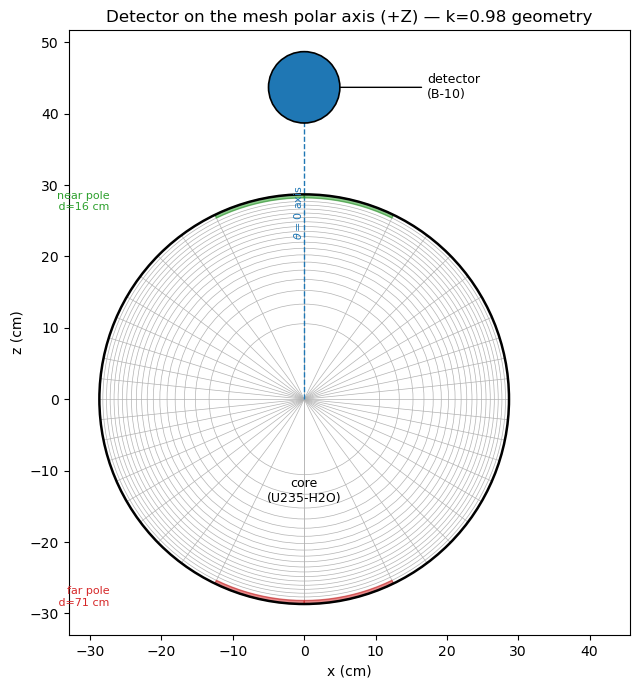

In [2]:
fig, ax = plt.subplots(figsize=(6.5, 7.5))
gl.plot_geometry_mesh(ax, R, n_r=n_r, n_th=n_th)
ax.set_title("Detector on the mesh polar axis (+Z) — k=0.98 geometry")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "geometry_mesh.png", dpi=200, bbox_inches="tight")
plt.show()

## 1. Spatial Green's function $G_i(r,\theta)$

$G_i$ = expected detector captures per neutron emitted from cell $i$. The detector sits on the
$+Z$ axis, so $\cos\theta=+1$ is the detector-facing surface and $\cos\theta=-1$ is the far side.

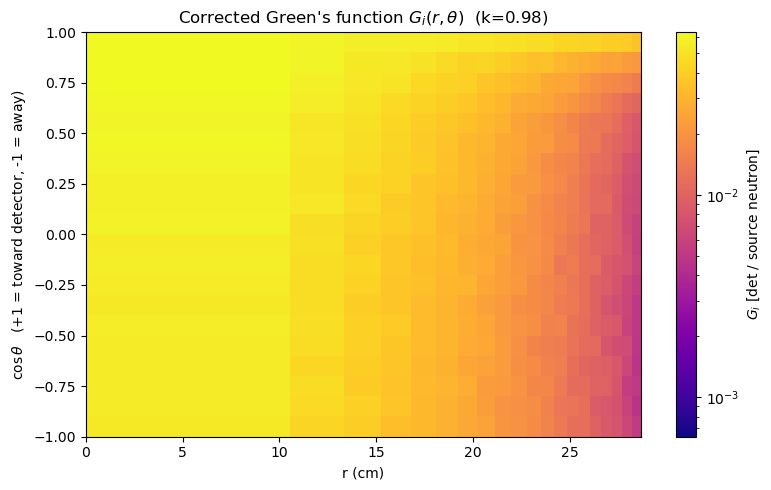

In [3]:
from matplotlib.colors import LogNorm

r_edges = sweep["r_edges"]; cos_edges = sweep["cos_edges"]
G_2d = sweep["G"]                       # (n_r, n_th)
norm = LogNorm(vmin=np.nanmax(G_2d) / 100, vmax=np.nanmax(G_2d))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(r_edges, cos_edges, G_2d.T, cmap="plasma", shading="flat", norm=norm)
plt.colorbar(im, ax=ax, label=r"$G_i$ [det / source neutron]")
ax.set_xlabel("r (cm)")
ax.set_ylabel(r"$\cos\theta$   (+1 = toward detector, -1 = away)")
ax.set_title(r"Corrected Green's function $G_i(r,\theta)$  (k=0.98)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Same $G_i$ as a polar meridional slice

The identical data on a physical cross-section of the core: disk centre = core centre, rim =
surface, **detector direction (θ=0) at the top**, far side (θ=π) at the bottom. Azimuthally
symmetric, so the left/right halves mirror.

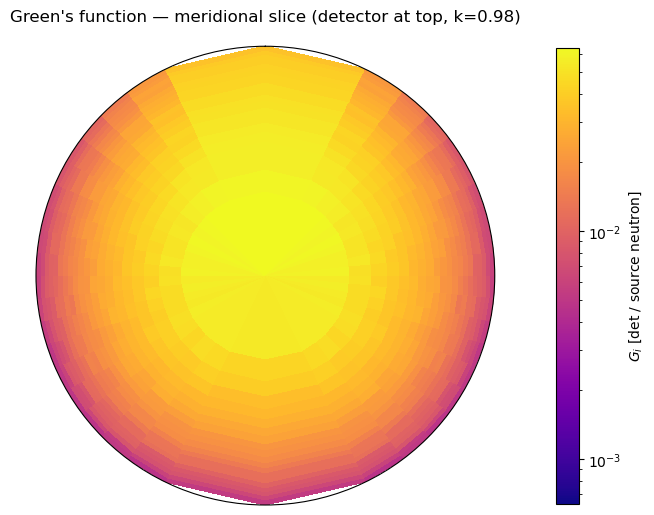

In [4]:
fig = plt.figure(figsize=(6.5, 6))
axp = fig.add_subplot(111, projection="polar")
imp = gl.polar_meridian(axp, sweep, norm=norm)
fig.colorbar(imp, ax=axp, label=r"$G_i$ [det / source neutron]", pad=0.10, shrink=0.8)
axp.set_title("Green's function — meridional slice (detector at top, k=0.98)", pad=18)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_polar.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Radial (importance) vs angular (distance) structure

The two physical effects separate cleanly:
* **Radial** $G(r)$ (marginalised over $\theta$) — the *importance* / fundamental-mode weight:
  a neutron deeper in the core is more likely to ignite a persistent chain. Near critical this
  is the dominant structure and is centre-peaked. We overlay the idealised bare-sphere fundamental
  mode $\mathrm{sinc}(r/R)=\sin(\pi r/R)/(\pi r/R)$ as a reference: the simulated $G(r)$ tracks it
  (centre-peaked), with a non-zero edge value expected from the extrapolation length and the direct
  surface-to-detector coupling that the idealised zero-flux-boundary mode omits.
* **Angular** $G(\theta)$ at fixed radius — the *direct geometric coupling* to the detector:
  cells facing the detector ($\cos\theta>0$) couple more strongly. This dominates far below
  critical and washes out as $k\to1$.

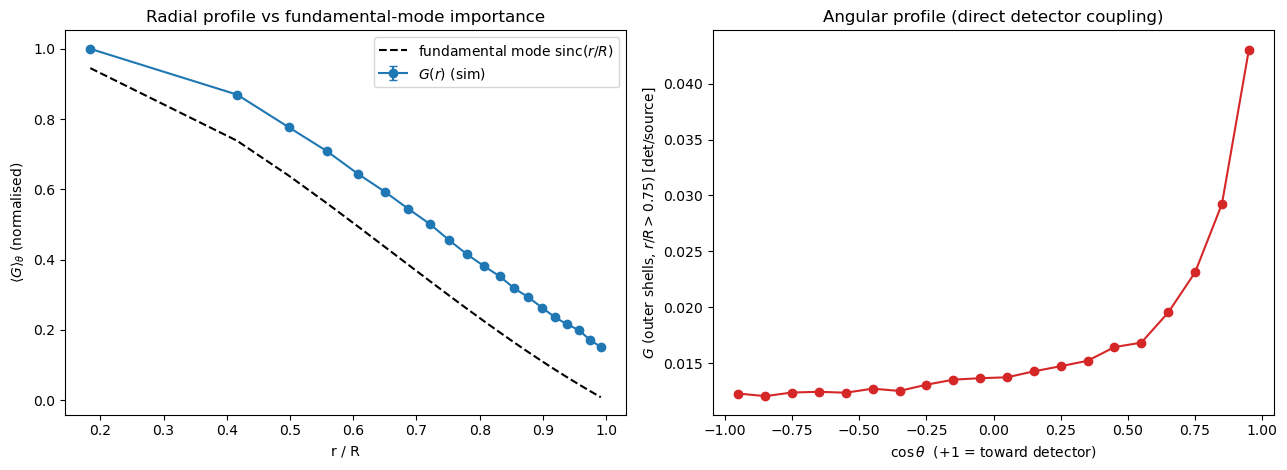

In [5]:
r1d, G_r, G_r_err = gl.radial_profile(sweep)
cos1d, G_th, G_th_err = gl.angular_profile(sweep, r_frac_min=0.75)  # outer shells
fund = gl.fundamental_mode_shape(r1d, R)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
gmax = G_r.max()
axes[0].errorbar(r1d / R, G_r / gmax, yerr=G_r_err / gmax, marker="o", capsize=3, label="$G(r)$ (sim)")
axes[0].plot(r1d / R, fund, "k--", lw=1.5, label=r"fundamental mode $\mathrm{sinc}(r/R)$")
axes[0].set_xlabel("r / R"); axes[0].set_ylabel(r"$\langle G\rangle_\theta$ (normalised)")
axes[0].set_title("Radial profile vs fundamental-mode importance")
axes[0].legend()

axes[1].errorbar(cos1d, G_th, yerr=G_th_err, marker="o", capsize=3, color="C3")
axes[1].set_xlabel(r"$\cos\theta$  (+1 = toward detector)")
axes[1].set_ylabel(r"$G$ (outer shells, $r/R>0.75$) [det/source]")
axes[1].set_title("Angular profile (direct detector coupling)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. $G$ vs distance to detector

The single clearest view of the effect the original (buggy) analysis was missing entirely:
$G$ falls steeply with the cell-to-detector distance.

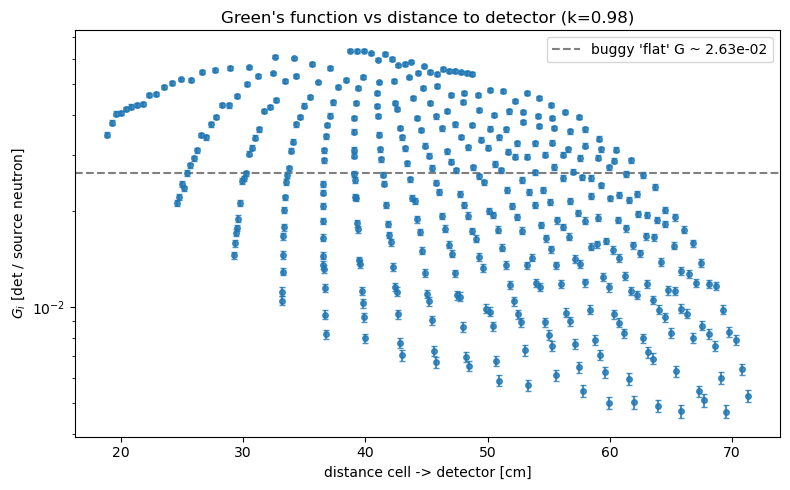

In [6]:
dist = sweep["dist"].ravel(); G = sweep["G"].ravel(); Gerr = sweep["G_err"].ravel()
order = np.argsort(dist)
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(dist[order], G[order], yerr=Gerr[order], fmt="o", ms=4, capsize=2, alpha=0.8)
ax.axhline(sweep["G"].mean(), ls="--", color="gray",
           label=f"buggy 'flat' G ~ {sweep['G'].mean():.2e}")
ax.set_yscale("log"); ax.set_xlabel("distance cell -> detector [cm]")
ax.set_ylabel(r"$G_i$ [det / source neutron]")
ax.set_title("Green's function vs distance to detector (k=0.98)")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_vs_distance.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Time-resolved $g_i(t)$

$g_i(t)$ for a near-pole (facing), far-pole and central cell. Near cells peak earlier and
higher; far cells are delayed and weaker.

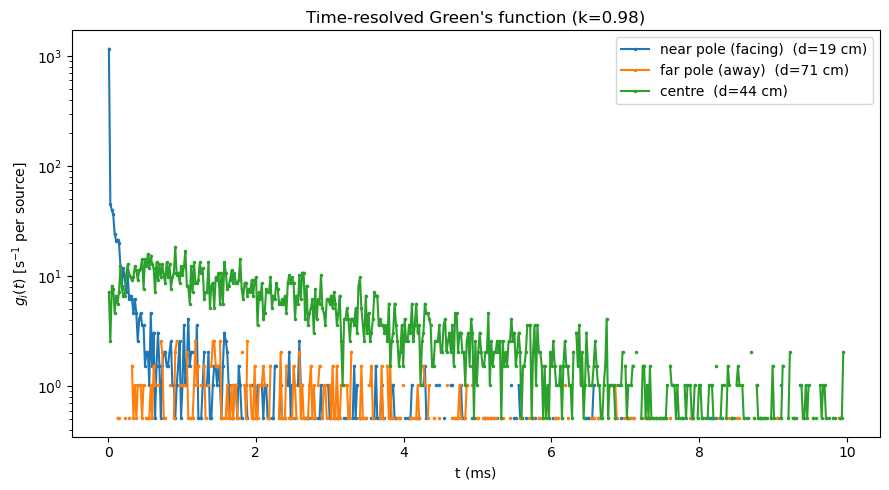

In [7]:
te = sweep["time_edges"]; tc = 0.5 * (te[:-1] + te[1:]); dt = te[1] - te[0]
n = float(sweep["n_source"])
picks = {
    "near pole (facing)": (n_r - 1, 0),
    "far pole (away)":    (n_r - 1, n_th - 1),
    "centre":             (0, n_th // 2),
}
fig, ax = plt.subplots(figsize=(9, 5))
for lbl, (ir, ith) in picks.items():
    g = sweep["g_t"][ir, ith] / (n * dt)        # per source per second
    gp = np.where(sweep["g_t"][ir, ith] > 0, g, np.nan)
    ax.plot(tc * 1e3, gp, marker=".", ms=3, label=f"{lbl}  (d={sweep['dist'][ir,ith]:.0f} cm)")
ax.set_yscale("log"); ax.set_xlabel("t (ms)")
ax.set_ylabel(r"$g_i(t)$ [s$^{-1}$ per source]")
ax.set_title("Time-resolved Green's function (k=0.98)")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "greens_function_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Rossi-alpha from the corrected $g_i(t)$

$R(\tau)=\sum_i F_i\int g_i(t)g_i(t+\tau)\,dt$, fit to $A+B e^{\alpha\tau}$.

The prompt decay constant $\alpha$ is the **fundamental eigenvalue** of the system — it lives
in the detection *times*, not in the spatial labels. That is why the original analysis recovered
a sensible $\alpha$ even though its spatial $G_i$ was scrambled: the bug shuffled *which cell*
each detection was assigned to, but never *when* it arrived. Spatial structure lives in the
amplitudes $F_i$ and $g_i$ shape; the decay rate does not.

alpha = -616.1 +/- 13.9 s^-1   (decay time = 1.623 ms)


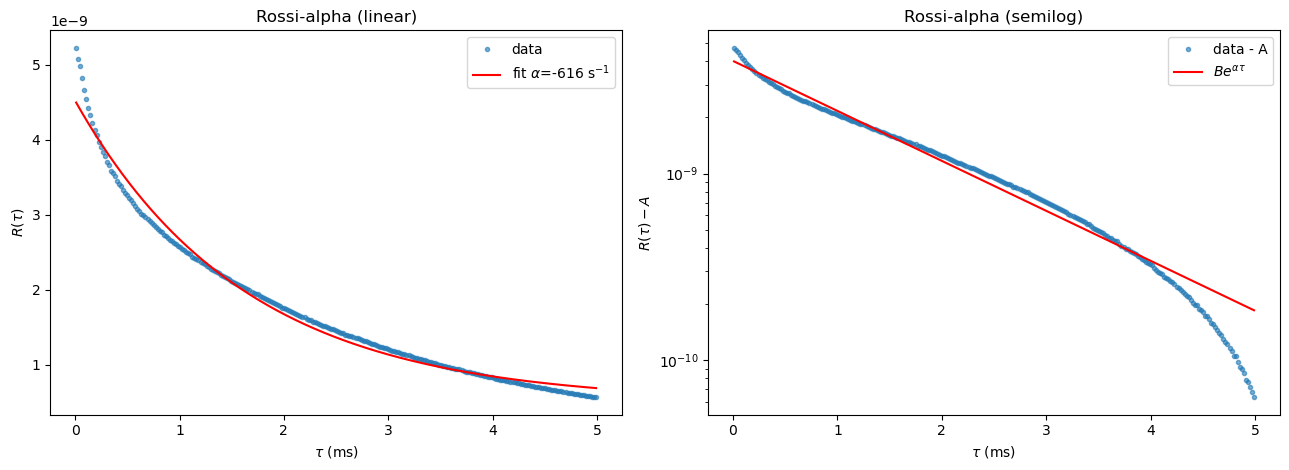

In [8]:
tau, R_tau = gl.rossi(sweep, F)
popt, perr = gl.fit_alpha(tau, R_tau)
alpha = popt[2]
print(f"alpha = {alpha:.1f} +/- {perr[2]:.1f} s^-1   (decay time = {-1/alpha*1e3:.3f} ms)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
tf = np.linspace(tau[0], tau[-1], 800)
axes[0].plot(tau*1e3, R_tau, "o", ms=3, alpha=0.6, label="data")
axes[0].plot(tf*1e3, gl.rossi_model(tf, *popt), "r-", lw=1.5, label=fr"fit $\alpha$={alpha:.0f} s$^{{-1}}$")
axes[0].set_xlabel(r"$\tau$ (ms)"); axes[0].set_ylabel(r"$R(\tau)$")
axes[0].set_title("Rossi-alpha (linear)"); axes[0].legend()

R_corr = np.where(R_tau - popt[0] > 0, R_tau - popt[0], np.nan)
axes[1].semilogy(tau*1e3, R_corr, "o", ms=3, alpha=0.6, label="data - A")
axes[1].semilogy(tf*1e3, gl.rossi_model(tf, 0, popt[1], alpha), "r-", lw=1.5,
                 label=fr"$Be^{{\alpha\tau}}$")
axes[1].set_xlabel(r"$\tau$ (ms)"); axes[1].set_ylabel(r"$R(\tau)-A$")
axes[1].set_title("Rossi-alpha (semilog)"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_alpha.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

* Corrected $G_i$ spans nearly two decades across the core (vs the buggy flat $\sim$const).
* Two structures: **radial importance** (centre-peaked, dominant near critical) and **angular
  distance-to-detector coupling** (facing $>$ away, dominant far below critical).
* The Rossi $\alpha$ is unchanged by the fix, as expected — it is carried by detection times.

In [9]:
print("="*54)
print("GREEN'S FUNCTION ANALYSIS (corrected) — k =", sweep["k"])
print("="*54)
print(f"G(min..max)            : {sweep['G'].min():.3e} .. {sweep['G'].max():.3e}")
print(f"G(near/far pole)       : {sweep['G'][-1,0]/sweep['G'][-1,-1]:.1f}x")
print(f"alpha                  : {alpha:.1f} s^-1  (tau = {-1/alpha*1e3:.3f} ms)")

GREEN'S FUNCTION ANALYSIS (corrected) — k = 0.98
G(min..max)            : 4.690e-03 .. 6.371e-02
G(near/far pole)       : 6.6x
alpha                  : -616.1 s^-1  (tau = 1.623 ms)
